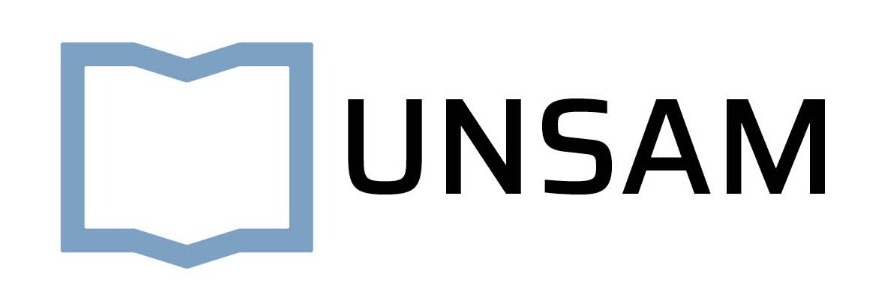

# APS : TS4 Castiñeira 

## Autor: Santiago Castiñeira

## Introduccion:

En esta tarea se continúa trabajando con **análisis espectral**, pero ahora se busca ver cómo distintas ventanas afectan la estimación de la amplitud y la frecuencia de una señal senoidal con ruido.

Para esto se realizan varias simulaciones cambiando ligeramente la frecuencia de la señal y utilizando distintos niveles de **SNR**.

### Punto 1:
En este punto se realizan **200 realizaciones** de una señal de **1000 muestras** para valores de SNR de **3 dB** y **10 dB**.

Para generar todas las señales se trabaja de forma matricial, usando las frecuencias aleatorias como un vector columna y las muestras como un vector fila.

Luego se aplican cuatro ventanas diferentes y se comparan las estimaciones de amplitud y frecuencia mediante histogramas.


In [6]:
#%% Librerías

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as window


#%% Parámetros

N = 1000                     # cantidad de muestras
R = 200                      # cantidad de realizaciones

a0 = np.sqrt(2)              # amplitud -> potencia de la senoide = 1 W
Omega0 = np.pi/2             # frecuencia central [rad/muestra]

SNR_valores = [3, 10]


#%% Vectores para generar las 200 señales

# Vector fila de 1000 muestras
n = np.arange(N).reshape(1, N)       # tamaño 1 x 1000

# Vector columna con 200 valores aleatorios  -2 a 2
fr = np.random.uniform(-2, 2, size=(R, 1))   # tamaño 200 x 1

# Frecuencia real de cada una de las 200 realizaciones
Omega1 = Omega0 + fr * (2*np.pi/N)   # tamaño 200 x 1

In [7]:
#%% Ventanas

rectangular = np.ones(N)
flattop = window.flattop(N)
blackmanharris = window.blackmanharris(N)
hann = window.hann(N)

ventanas = [rectangular,
            flattop,
            blackmanharris,
            hann]

nombres = ['Rectangular',
           'Flattop',
           'Blackman-Harris',
           'Hann']

Las ventanas se usan para modificar la forma en que aparece la señal en frecuencia.

No todas hacen lo mismo: algunas permiten distinguir mejor frecuencias cercanas y otras reducen más el desparramo o ayudan a medir mejor la amplitud.

La ventana **rectangular** prácticamente no modifica la señal y tiene un pico principal más angosto, pero presenta más lóbulos laterales.

La **Hann** reduce esos lóbulos y sirve como una opción intermedia.

La **Blackman-Harris** busca reducir todavía más el desparramo, aunque ensancha más el pico principal.

La **flattop**, en cambio, se usa especialmente cuando interesa estimar con mayor precisión la amplitud de una componente.

En esta parte la idea es generar las **200 señales** para los dos valores de **SNR** y después probar las cuatro ventanas sobre esas mismas señales.

Para no ir armando cada realización una por una, las señales se generan todas juntas en una matriz.

Después se usa un `for` para repetir el experimento con SNR de **3 dB** y **10 dB**, y dentro de cada caso se aplica cada ventana, se calcula la **FFT** y se guardan las estimaciones de amplitud y frecuencia.

In [14]:
#%% Experimento

for SNR in SNR_valores:

    # Potencia de la señal = 1 W
    P_senal = 1

    # Potencia y desvío del ruido según el SNR
    P_ruido = P_senal / (10**(SNR/10))
    sigma_ruido = np.sqrt(P_ruido)

    # Generamos las 200 señales con ruido
    na = np.random.normal(0, sigma_ruido, size=(R, N))

    x = a0 * np.sin(Omega1 * n) + na

    # Acá se guardan los resultados de las 4 ventanas
    amplitudes = np.zeros((4, R))
    frecuencias = np.zeros((4, R))


    # Aplicamos las cuatro ventanas
    for i in range(4):

        w = ventanas[i]

        # Aplicamos la ventana
        xw = x * w

        # FFT de las 200 realizaciones
        Xw = np.fft.rfft(xw, axis=1)

        # Módulo corregido según la ganancia de la ventana
        modulo = (2 / np.sum(w)) * np.abs(Xw)

        # Estimación de amplitud en Omega0
        amplitudes[i, :] = modulo[:, k0]

        # Estimación de frecuencia buscando el máximo
        k_max = np.argmax(modulo, axis=1)

        frecuencias[i, :] = 2*np.pi*k_max/N


    # Guardamos por separado los resultados de cada SNR
    if SNR == 3:

        amplitudes_3dB = amplitudes.copy()
        frecuencias_3dB = frecuencias.copy()

    if SNR == 10:

        amplitudes_10dB = amplitudes.copy()
        frecuencias_10dB = frecuencias.copy()

Con este código se obtienen **200 estimaciones de amplitud** y **200 de frecuencia** para cada ventana y para cada valor de **SNR**.

De esta forma quedan guardados todos los resultados necesarios para después compararlos con los histogramas y ver cómo cambia cada estimación según la ventana y el nivel de ruido.
    

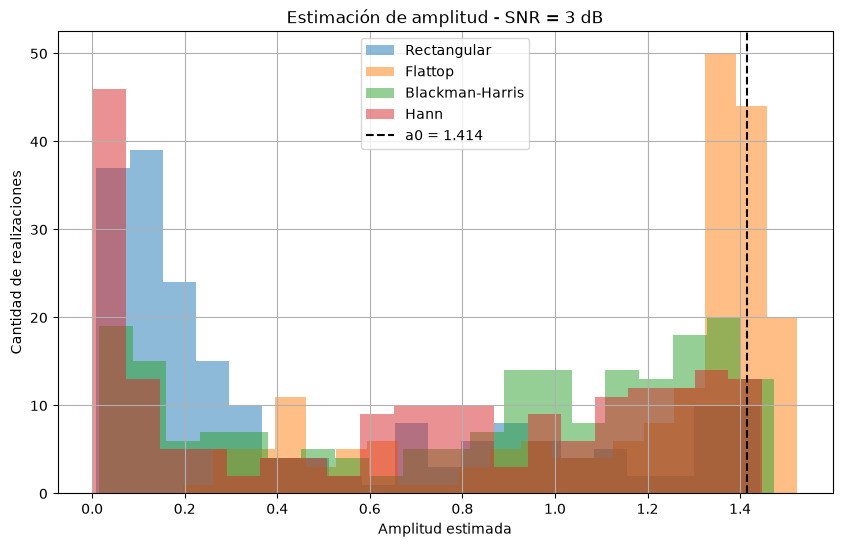

In [15]:
#%% Histograma de amplitud - SNR = 3 dB

plt.figure(figsize=(10,6))

for i in range(4):

    plt.hist(amplitudes_3dB[i, :],
             bins=20,
             alpha=0.5,
             label=nombres[i])

plt.axvline(a0,
            color='black',
            linestyle='--',
            label=f'a0 = {a0:.3f}')

plt.title('Estimación de amplitud - SNR = 3 dB')
plt.xlabel('Amplitud estimada')
plt.ylabel('Cantidad de realizaciones')
plt.grid(True)
plt.legend()

plt.show()

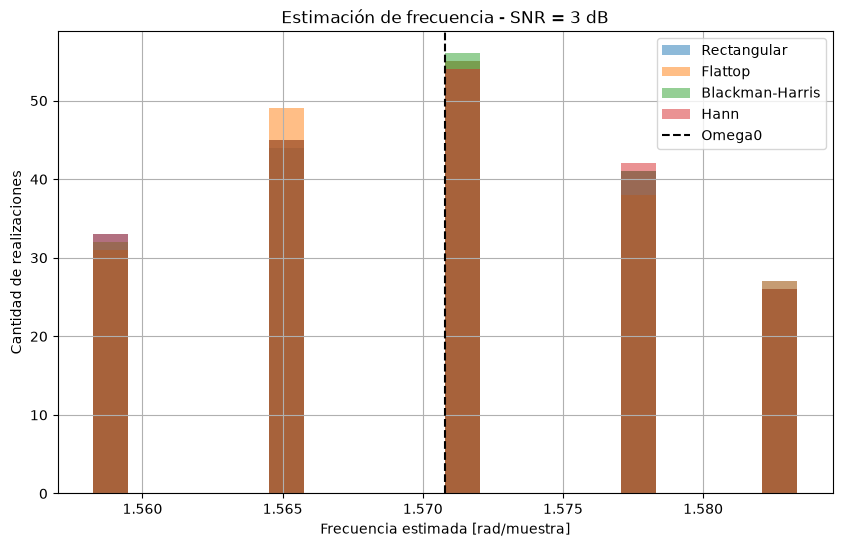

In [16]:
  #%% Histograma de frecuencia - SNR = 3 dB

plt.figure(figsize=(10,6))

for i in range(4):

    plt.hist(frecuencias_3dB[i, :],
             bins=20,
             alpha=0.5,
             label=nombres[i])

# Frecuencia central
plt.axvline(Omega0,
            color='black',
            linestyle='--',
            label='Omega0')

plt.title('Estimación de frecuencia - SNR = 3 dB')
plt.xlabel('Frecuencia estimada [rad/muestra]')
plt.ylabel('Cantidad de realizaciones')
plt.grid(True)
plt.legend()

plt.show()

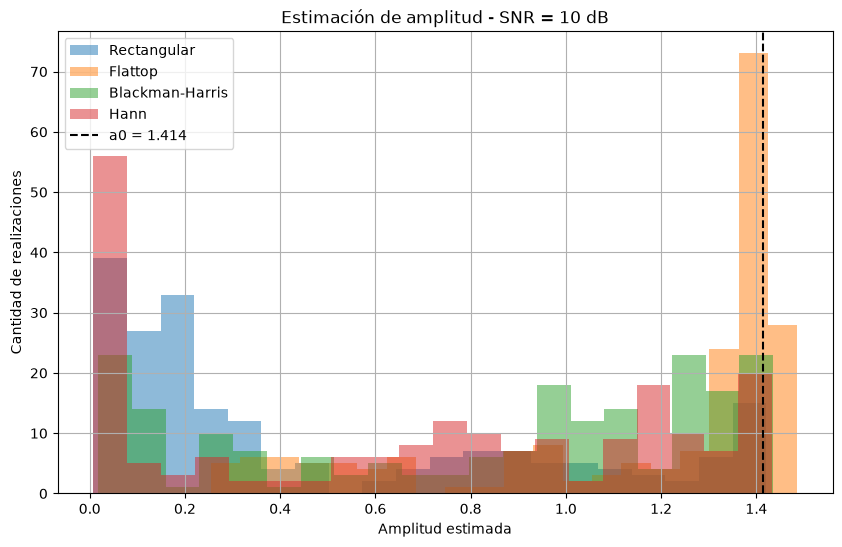

In [17]:
#%% Histograma de amplitud - SNR = 10 dB

plt.figure(figsize=(10,6))

for i in range(4):

    plt.hist(amplitudes_10dB[i, :],
             bins=20,
             alpha=0.5,
             label=nombres[i])

plt.axvline(a0,
            color='black',
            linestyle='--',
            label=f'a0 = {a0:.3f}')

plt.title('Estimación de amplitud - SNR = 10 dB')
plt.xlabel('Amplitud estimada')
plt.ylabel('Cantidad de realizaciones')
plt.grid(True)
plt.legend()

plt.show()

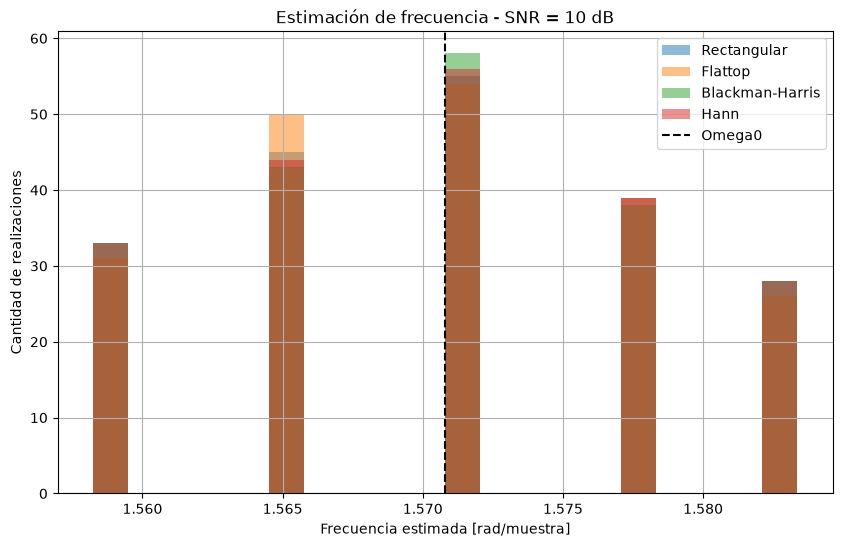

In [18]:
#%% Histograma de frecuencia - SNR = 10 dB

plt.figure(figsize=(10,6))

for i in range(4):

    plt.hist(frecuencias_10dB[i, :],
             bins=20,
             alpha=0.5,
             label=nombres[i])

plt.axvline(Omega0,
            color='black',
            linestyle='--',
            label='Omega0')

plt.title('Estimación de frecuencia - SNR = 10 dB')
plt.xlabel('Frecuencia estimada [rad/muestra]')
plt.ylabel('Cantidad de realizaciones')
plt.grid(True)
plt.legend()

plt.show()

Comparando los resultados de **3 dB** y **10 dB** se puede ver que con **3 dB** el ruido tiene más peso y las estimaciones aparecen más dispersas.

En cambio, para **10 dB** la señal tiene menos ruido en relación con la senoide y los resultados se concentran un poco más alrededor de los valores esperados.

También se puede ver que las distintas ventanas no se comportan exactamente igual: algunas dan mejores resultados para estimar la amplitud y otras generan una distribución distinta en frecuencia.

En el caso de la frecuencia, los valores aparecen en posiciones determinadas porque el estimador busca el máximo entre los bins de la **FFT**.